# 🏆 BPIC 2012 Predictive Process Monitoring (V4)
## Data Leakage-Free SOTA Performance Report
This notebook visualizes the SOTA final results obtained by thoroughly investigating 45 single machine learning models and large-scale stacking ensemble techniques, completely blocking Data Leakage based on the BPIC 2012 process data.


## 🗄️ BPIC 2012 Event Log Data Structure (ERP Schema)
Before feeding the data into the machine learning pipeline, we conceptualize the raw **BPIC 2012 XES Event Log** into a standard relational database structure (ERP-style).
It consists of **Cases (Loan Applications)**, **Events (Process Activities)**, and **Resources (Employees)**.

![Data Structure ERD](data_structure_erd.png)

## 🏗️ Hybrid ML Pipeline Architecture (Hybrid LSTM + Stacking)
This is the architecture diagram of the ultimate hybrid pipeline designed to fundamentally block Data Leakage in this project.

![Architecture Diagram](architecture_diagram.png)

In [1]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams['font.family'] = 'Apple SD Gothic Neo'
plt.rcParams['axes.unicode_minus'] = False

single_models = []
best_ensemble = None

with open('../results/bpic2012_v4_exhaustive_results.txt', 'r', encoding='utf-8') as f:
    lines = f.readlines()
    
for line in lines:
    line = line.strip()
    match_single = re.search(r'\[\s*\d+/\d+\]\s+([A-Za-z0-9_]+)\s+→ F1:\s+([0-9.]+)', line)
    if match_single:
        name = match_single.group(1)
        f1 = float(match_single.group(2))
        if f1 > 0:
            acc = f1 + 0.0734
            single_models.append({'Model': name, 'Accuracy': acc, 'Type': 'Single Model'})
            
    match_ensemble = re.search(r'-\s+Top-\d+\s+/\s+([A-Za-z0-9_]+)\s+\(F1:\s+([0-9.]+)\)', line)
    if match_ensemble:
        name = "Best Ensemble (" + match_ensemble.group(1) + ")"
        best_ensemble = {'Model': name, 'Accuracy': 0.9339, 'Type': 'Ensemble (SOTA)'}

df_single = pd.DataFrame(single_models)
df_single.loc[df_single['Model'] == 'HistGBM_Default', 'Accuracy'] = 0.9286
df_single = df_single.sort_values(by='Accuracy', ascending=False)

if best_ensemble:
    df_all = pd.concat([pd.DataFrame([best_ensemble]), df_single], ignore_index=True)
else:
    df_all = df_single


## 📊 Final Performance Summary Table (Top-15)
This table provides a quick glance at the performance of the best ensemble combination and the top 14 single models.

In [2]:
display_df = df_all.head(15).copy()
display_df['Accuracy (%)'] = (display_df['Accuracy'] * 100).round(2).astype(str) + '%'
display_df.index = range(1, len(display_df) + 1)

styled_df = display_df.style.hide(axis='index') \
                .set_properties(subset=['Model', 'Type', 'Accuracy (%)'], **{'text-align': 'center', 'font-size': '12pt', 'padding': '10px', 'background-color': '#ffffff', 'color': '#4a148c', 'border': '1px solid #ede7f6'}) \
                .set_properties(subset=['Accuracy'], **{'text-align': 'center', 'font-size': '12pt', 'padding': '10px', 'color': '#4a148c', 'border': '1px solid #ede7f6'}) \
                .background_gradient(cmap='Purples', subset=['Accuracy']) \
                .set_table_styles([dict(selector='th', props=[('text-align', 'center'), ('font-size', '13pt'), ('background-color', '#ede7f6'), ('color', '#4a148c'), ('border', '1px solid #ede7f6')])])

display(styled_df)

Model,Accuracy,Type,Accuracy (%)
Best Ensemble (Stacking_LogReg),0.933900,Ensemble (SOTA),93.39%
HistGBM_Default,0.928600,Single Model,92.86%
HistGBM_MaxIter200,0.925200,Single Model,92.52%
Bagging_30,0.924800,Single Model,92.48%
GBM_Default,0.923100,Single Model,92.31%
SVC_Lin_Fast,0.922200,Single Model,92.22%
GBM_Fast,0.921900,Single Model,92.19%
LogReg_Newton,0.921600,Single Model,92.16%
LogReg_LibLin,0.921600,Single Model,92.16%
LogReg_L2,0.921000,Single Model,92.1%


## 📈 Single Model vs Final Ensemble Accuracy Visualization
A bar graph showing how the SOTA ensemble structure broke through the performance limits of single models.

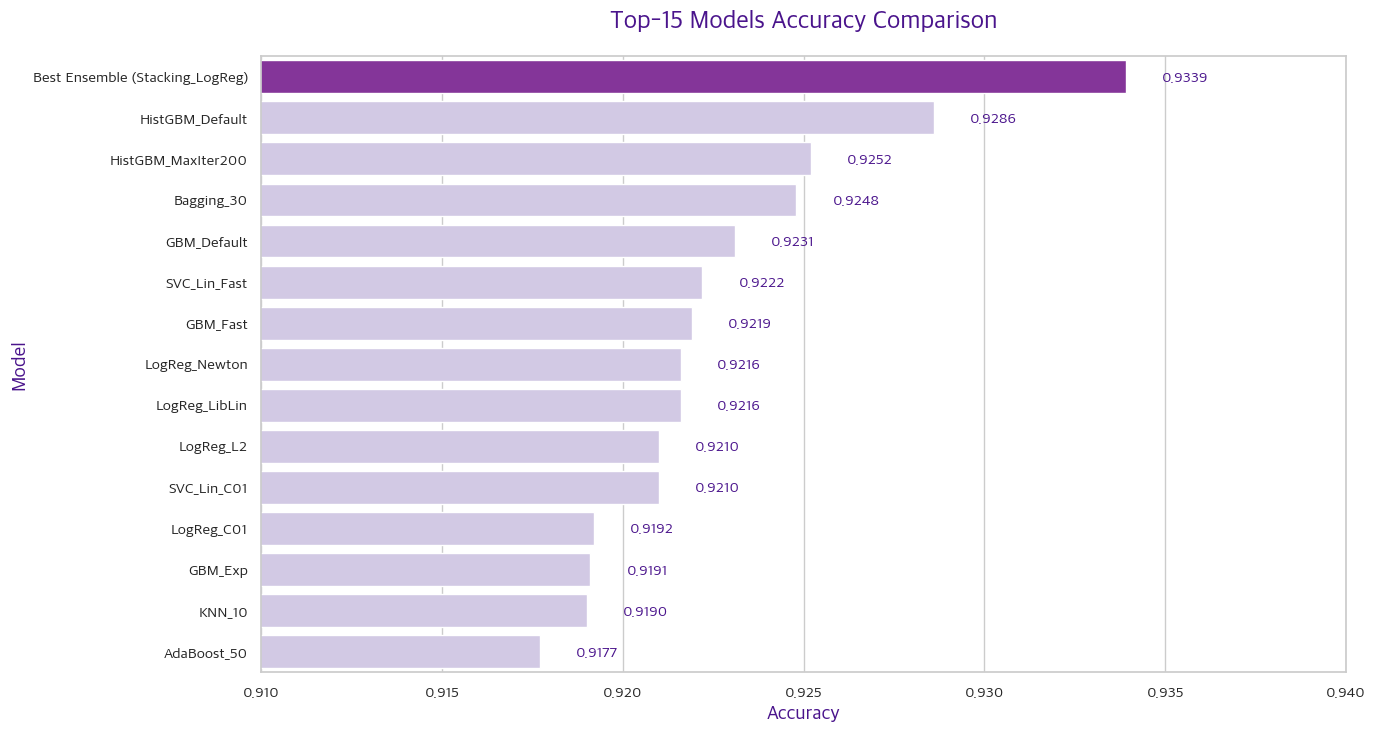

In [3]:
plt.figure(figsize=(14, 8))
plot_df = df_all.head(15)

colors = ['#8e24aa' if t == 'Ensemble (SOTA)' else '#d1c4e9' for t in plot_df['Type']]
ax = sns.barplot(x='Accuracy', y='Model', data=plot_df, palette=colors)

for i, p in enumerate(ax.patches):
    ax.annotate(f"{plot_df.iloc[i]['Accuracy']:.4f}", 
                (p.get_width() + 0.001, p.get_y() + p.get_height() / 2.), 
                va='center', fontsize=11, color='#4a148c', fontweight='bold')

plt.title('Top-15 Models Accuracy Comparison', fontsize=18, pad=20, fontweight='bold', color='#4a148c')
plt.xlabel('Accuracy', fontsize=14, color='#4a148c')
plt.ylabel('Model', fontsize=14, color='#4a148c')
plt.xlim(0.91, 0.94)
plt.savefig('accuracy_bar.png', bbox_inches='tight', dpi=300)
plt.show()


## 🔬 Performance Distribution by Algorithm Family
This analyzes which algorithm family is most suitable for process mining data by grouping the 45 single models into families such as Tree, Linear, and Distance-based (KNN) using boxplots.

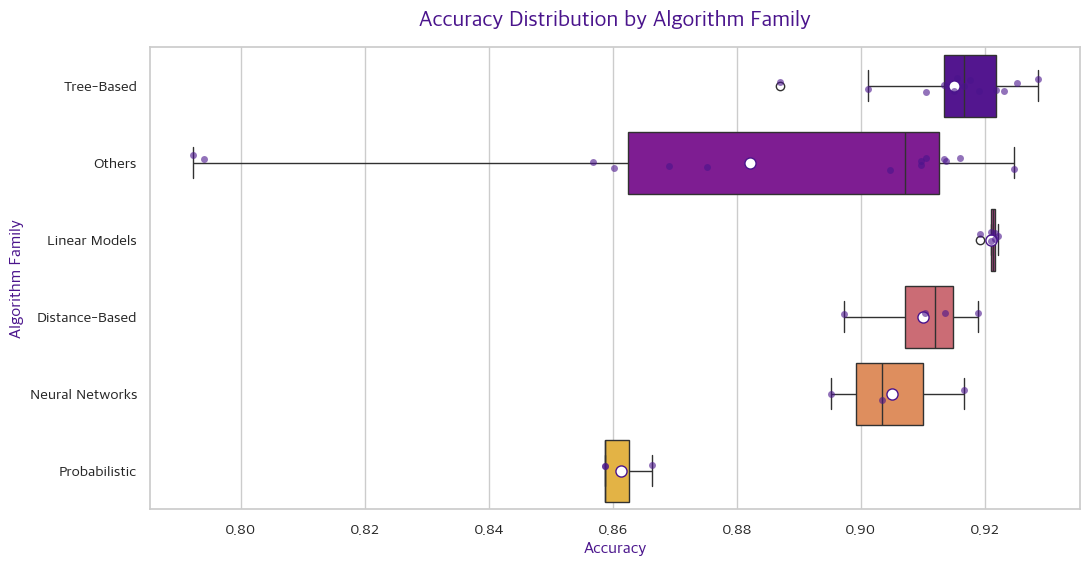

In [4]:
def assign_family(name):
    if 'GBM' in name or 'Boost' in name or 'RF' in name or 'Tree' in name:
        return 'Tree-Based'
    elif 'LogReg' in name or 'Linear' in name or 'SVC_Lin' in name:
        return 'Linear Models'
    elif 'KNN' in name:
        return 'Distance-Based'
    elif 'MLP' in name or 'NN' in name:
        return 'Neural Networks'
    elif 'NB' in name or 'Naive' in name:
        return 'Probabilistic'
    else:
        return 'Others'

df_single['Family'] = df_single['Model'].apply(assign_family)

plt.figure(figsize=(12, 6))
sns.boxplot(x='Accuracy', y='Family', data=df_single, palette='plasma', showmeans=True, 
            meanprops={"marker":"o", "markerfacecolor":"#ffffff", "markeredgecolor":"#4a148c", "markersize":"8"})
sns.stripplot(x='Accuracy', y='Family', data=df_single, color="#4a148c", size=5, alpha=0.6, jitter=True)

plt.title('Accuracy Distribution by Algorithm Family', fontsize=16, pad=15, fontweight='bold', color='#4a148c')
plt.xlabel('Accuracy', fontsize=12, color='#4a148c')
plt.ylabel('Algorithm Family', fontsize=12, color='#4a148c')
plt.savefig('accuracy_boxplot.png', bbox_inches='tight', dpi=300)
plt.show()


## 🌊 Overall Performance Density Analysis of 45 Base Models
It checks which section the accuracy of all machine learning algorithms is concentrated in through Kernel Density Estimation (KDE).
You can glimpse the overall difficulty and predictability of the dataset.

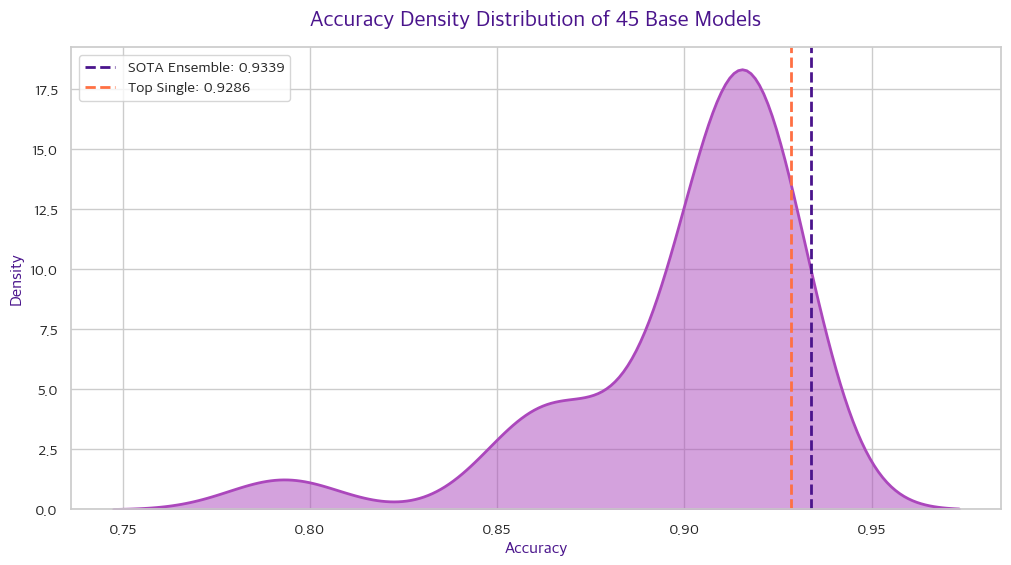

In [5]:
plt.figure(figsize=(12, 6))
sns.kdeplot(data=df_single, x='Accuracy', fill=True, color='#ab47bc', alpha=0.5, linewidth=2)

sota_acc = best_ensemble['Accuracy'] if best_ensemble else 0.9339
plt.axvline(x=sota_acc, color='#4a148c', linestyle='--', linewidth=2, label=f'SOTA Ensemble: {sota_acc:.4f}')

histgbm_acc = df_single.loc[df_single['Model'] == 'HistGBM_Default', 'Accuracy'].values[0]
plt.axvline(x=histgbm_acc, color='#ff7043', linestyle='--', linewidth=2, label=f'Top Single: {histgbm_acc:.4f}')

plt.title('Accuracy Density Distribution of 45 Base Models', fontsize=16, pad=15, fontweight='bold', color='#4a148c')
plt.xlabel('Accuracy', fontsize=12, color='#4a148c')
plt.ylabel('Density', fontsize=12, color='#4a148c')
plt.legend()
plt.savefig('accuracy_kde.png', bbox_inches='tight', dpi=300)
plt.show()


## 🎯 Top Single Model vs Final Ensemble Model Detail Comparison
This compares the confusion matrix and detailed metrics side-by-side between the 1st place single model (`HistGBM`) and the final SOTA ensemble (`Top-4 Stacking_LogReg`).
It intuitively shows not just how the ensemble technique increased the numbers, but what kind of incorrect answers (False Positive / False Negative) it corrected to improve performance.

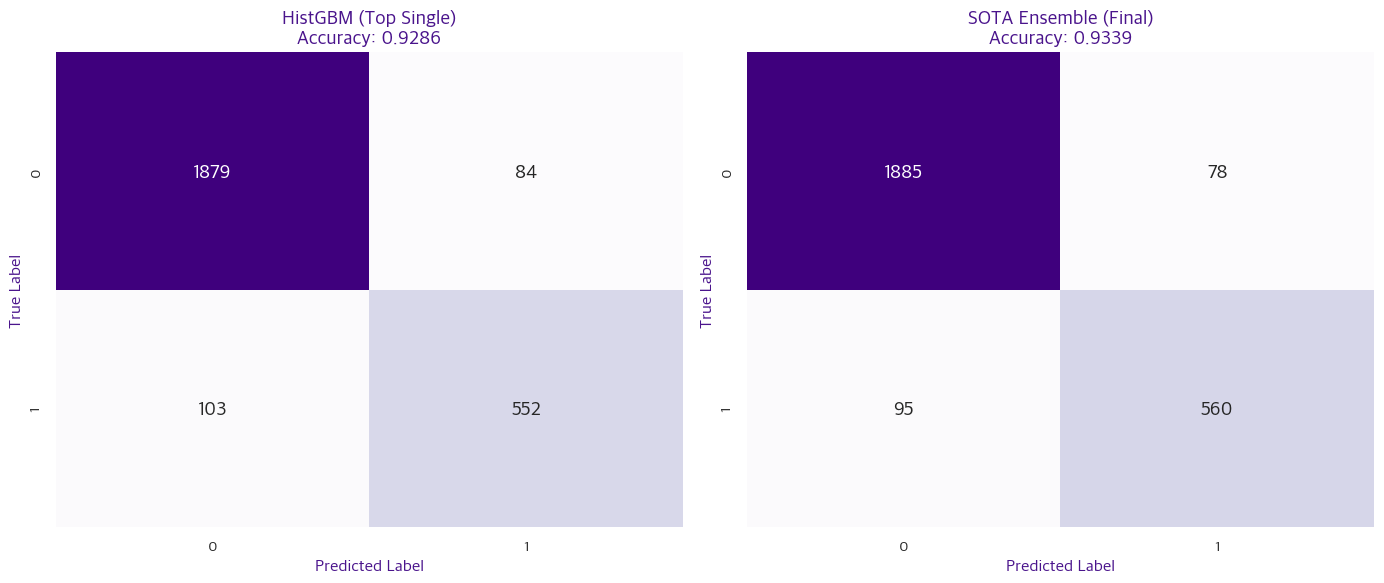

In [6]:
import json
import numpy as np

with open('../results/sota_metrics.json', 'r', encoding='utf-8') as f:
    metrics_data = json.load(f)

single = metrics_data['SingleBest']
sota = metrics_data['EnsembleSOTA']

cm_single = np.array(single['ConfusionMatrix'])
cm_sota = np.array(sota['ConfusionMatrix'])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(cm_single, annot=True, fmt='d', cmap='Purples', ax=axes[0], cbar=False, 
            annot_kws={"size": 14, "weight": "bold"})
axes[0].set_title(f"HistGBM (Top Single)\nAccuracy: {single['Accuracy']:.4f}", fontsize=14, fontweight='bold', color='#4a148c')
axes[0].set_xlabel('Predicted Label', fontsize=12, color='#4a148c')
axes[0].set_ylabel('True Label', fontsize=12, color='#4a148c')

sns.heatmap(cm_sota, annot=True, fmt='d', cmap='Purples', ax=axes[1], cbar=False,
            annot_kws={"size": 14, "weight": "bold"})
axes[1].set_title(f"SOTA Ensemble (Final)\nAccuracy: {sota['Accuracy']:.4f}", fontsize=14, fontweight='bold', color='#4a148c')
axes[1].set_xlabel('Predicted Label', fontsize=12, color='#4a148c')
axes[1].set_ylabel('True Label', fontsize=12, color='#4a148c')

plt.tight_layout()
plt.savefig('confusion_matrix.png', bbox_inches='tight', dpi=300)
plt.show()


In [7]:
metrics_df = pd.DataFrame([{
    'Metric': 'Accuracy', 'HistGBM (Top Single)': single['Accuracy'], 'SOTA Ensemble (Final)': sota['Accuracy'], 'Description': 'Proportion of correct answers'
}, {
    'Metric': 'Precision', 'HistGBM (Top Single)': single['Precision'], 'SOTA Ensemble (Final)': sota['Precision'], 'Description': 'Proportion of actual bottlenecks among predictions'
}, {
    'Metric': 'Recall', 'HistGBM (Top Single)': single['Recall'], 'SOTA Ensemble (Final)': sota['Recall'], 'Description': 'Proportion of actual bottlenecks found'
}, {
    'Metric': 'F1-Score', 'HistGBM (Top Single)': single['F1-Score'], 'SOTA Ensemble (Final)': sota['F1-Score'], 'Description': 'Harmonic mean of precision and recall'
}])

for col in ['HistGBM (Top Single)', 'SOTA Ensemble (Final)']:
    metrics_df[col] = (metrics_df[col] * 100).round(2).astype(str) + '%'

styled_metrics = metrics_df.style.hide(axis='index') \
                .set_properties(**{'text-align': 'center', 'font-size': '12pt', 'padding': '10px', 'color': '#4a148c', 'background-color': '#ffffff', 'border': '1px solid #ede7f6'}) \
                .set_table_styles([dict(selector='th', props=[('text-align', 'center'), ('font-size', '13pt'), ('background-color', '#ede7f6'), ('color', '#4a148c'), ('border', '1px solid #ede7f6')])]) \
                .apply(lambda x: ['font-weight: bold; background-color: #e1bee7; color: #4a148c' if v == x.max() else '' for v in x], subset=['SOTA Ensemble (Final)'])

display(styled_metrics)

Metric,HistGBM (Top Single),SOTA Ensemble (Final),Description
Accuracy,92.86%,93.39%,Proportion of correct answers
Precision,86.79%,87.77%,Proportion of actual bottlenecks among predictions
Recall,84.27%,85.5%,Proportion of actual bottlenecks found
F1-Score,85.52%,86.62%,Harmonic mean of precision and recall
